# 平均も標準偏差も合っているのに、裾の点が低いのはなぜ？

このノートは、有用性の観点 $U_\text{gen}$（一般有用性）の中にある**裾の一致（tail）**を扱います（ルールブック §6.1.1）。

**ここで採点する観点**

- 検査値の分布の両端（極端に高い値・低い値の出方）が、本物と同じか。両端を削ったり丸めたりしたデータで基準値を外れた人の数を数えると、本物とは違う人数になります。ノイズで極端な値が本物より多く出るようになったデータでも同じです。

所要 15 分。

## 0. 準備

練習データ（`participant_data/B_practice.csv`）を使います。

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

# 配布データの場所を探す（リポジトリの配置でも、zip を展開しただけの配置でも動くように）
DATA = next(p for p in (Path('..'), Path('../participant_data'), Path('participant_data'))
            if (p / 'B_practice.csv').exists())

from pwscup2026.kit import selfscore as ss        # CodaBench と同じ採点器

B_ref, REF, CFG, info = ss.load_local_reference(DATA)   # 採点器が使う参照値とパラメータ

# 採点と同じ読み方で読む（float_precision='round_trip'）。既定の読み方だと小数の末尾の桁がずれ、
# 値を変えていない列でも点数がごくわずかに下がることがあります。
B = pd.read_csv(DATA / 'B_practice.csv', float_precision='round_trip')

def score(C: pd.DataFrame) -> dict:
    # C を採点して {utility, facets, detail} を返す（CodaBench と同じ採点器）
    return ss.self_score(C.copy(), B_ref, REF, CFG)

print(f'B: {B.shape[0]} 行 × {B.shape[1]} 列')

B: 1049 行 × 14 列


## 1. 何を比べるか

比べるのは、分布の**両端**の値（分位点）です。p パーセンタイルは、値を小さい順に並べて p% の位置にある値で、95 パーセンタイルならそれより大きい人がおよそ 5% います。

- 6つの検査値（BMI・SBP・TG・HDL・ALT・FPG）それぞれの、上側 95・99・99.9 パーセンタイルと、下側 5・1・0.1 パーセンタイル（1つの検査値あたり6個）
- 年齢と6つの検査値から求めた外れ度（マハラノビス距離）の、上側 95・99・99.9 パーセンタイル。マハラノビス距離は、その人の値の組み合わせが、多数派（希少群を除いた 2型群）の分布の中心からどれだけ離れているかを、列どうしの相関も考えに入れて測った距離です。

候補は合わせて 39 個で、そのうち採点に入るのは **36 個**です。残りの 3 個は、本物のデータでの標準偏差（ばらつき）が、背景データ $A_\text{bg}$ から見積もった標準偏差より4割を超えて大きく、$A_\text{bg}$ から作る物差しが当てにならないので、採点に入れていません。どれが入るかは `scoring_config.yaml` の表で決まっています。

In [2]:
from pwscup2026.rare import outlier
from pwscup2026.common import schema

LABS = ['BMI', 'SBP', 'TG', 'HDL', 'ALT', 'FPG']
UP, DN = (95, 99, 99.9), (5, 1, 0.1)
T = CFG['scoring']['u_gen']['tail']            # 採点パラメータ（scoring_config.yaml）

def qname(col, q):
    return f"{col}_q{int(q) if float(q).is_integer() else q}"

def tail_stats(df):
    # 検査値6列の6分位点と、外れ度の上側3分位点
    out = {qname(c, q): float(np.percentile(df[c], q)) for c in LABS for q in (0.1, 1, 5, 95, 99, 99.9)}
    d = outlier.mahalanobis(df, REF.mu, REF.sigma, schema.CONTINUOUS)
    out.update({qname('maha', q): float(np.percentile(d, q)) for q in UP})
    return out

UP_NAMES = [qname(c, q) for c in LABS for q in UP] + [qname('maha', q) for q in UP]
DN_NAMES = [qname(c, q) for c in LABS for q in DN]
USED = [s for s in UP_NAMES + DN_NAMES if T['ratio'][s] <= T['ratio_max']]
SIGMA = {s: T['floor_sd'][s] * max(T['ratio'][s], 1.0) for s in USED}   # 差の物差し σ_k

print(f'分位点 {len(UP_NAMES) + len(DN_NAMES)} 個のうち、採点に入るもの {len(USED)} 個')
print('採点に入らないもの:', [s for s in UP_NAMES + DN_NAMES if s not in USED])

tB = tail_stats(B)
pd.DataFrame({'B での値': {s: tB[s] for s in USED if s.startswith('TG_')},
              'σ_k': {s: SIGMA[s] for s in USED if s.startswith('TG_')}}).round(3)

分位点 39 個のうち、採点に入るもの 36 個
採点に入らないもの: ['HDL_q99.9', 'FPG_q5', 'FPG_q1']


,B での値,σ_k
TG_q95,231.022,16.185
TG_q99,393.467,49.248
TG_q99.9,546.860,130.886
TG_q5,24.323,1.899
TG_q1,14.010,1.932
TG_q0.1,8.353,2.073


上は TG の例です。上側の 99.9 パーセンタイルの $\sigma_k$ がとくに大きいのは、1,049 人のうち上位のごく数人の値でこの値が決まり、標本のあいだの標準偏差が大きいためです。

## 2. 測り方

分位点 $k$ ごとに、差 $\Delta_k=(C\text{ での値})-(B\text{ での値})$ を取り、$z_k=\Delta_k/\sigma_k$ とします。

- **(a) 系統的なずれ**：上側の $z_k$ の平均を $\bar z_\text{up}$、下側の平均を $\bar z_\text{dn}$ とし、$z=\tfrac{1}{\sqrt2}\sqrt{(\bar z_\text{up}/c_\text{up})^2+(\bar z_\text{dn}/c_\text{dn})^2}$ にまとめます（$c_\text{up}$・$c_\text{dn}$ は `scoring_config.yaml` の `shift_norm_up`・`shift_norm_dn`）。$U_\text{shift}=\operatorname{clip}\bigl(1-\max(0,\,z-3)/5,\,0,\,1\bigr)$（$\operatorname{clip}(x,0,1)$ は、$x$ が 0 未満なら 0、1 を超えたら 1 にする操作）。
- **(b) 局所的なずれ**：許容幅 $d_k=\max\bigl(3\sigma_k,\ 0.05\times\mathrm{IQR}_B(k)\bigr)$（$\mathrm{IQR}_B(k)$ は $B$ での四分位範囲＝75 パーセンタイルと 25 パーセンタイルの差）で割って 1 を超えた分 $e_k=\min\bigl(\max(0,\,|\Delta_k|/d_k-1),\,10\bigr)$ の平均を $s$ とし、$U_\text{spike}=\operatorname{clip}\bigl(1-s/0.5,\,0,\,1\bigr)$。
- $\text{tail}=\min(U_\text{shift},\ U_\text{spike})$

ルールブックの式どおりに計算して、採点器の値と一致することを確かめます。

In [3]:
def tail_by_formula(C, B):
    # ルールブック §6.1.1 の裾の一致を式どおりに計算する
    tC, tB = tail_stats(C), tail_stats(B)
    iqr = {c: float(np.percentile(B[c], 75) - np.percentile(B[c], 25)) for c in LABS}
    dB = outlier.mahalanobis(B, REF.mu, REF.sigma, schema.CONTINUOUS)
    iqr['maha'] = float(np.percentile(dB, 75) - np.percentile(dB, 25))
    z, e = {}, []
    for s in USED:
        delta = tC[s] - tB[s]
        z[s] = delta / SIGMA[s]
        d_k = max(3 * SIGMA[s], T['iqr_guard'] * iqr[s.split('_q')[0]])
        e.append(min(max(0.0, abs(delta) / d_k - 1.0), T['spike_cap']))
    z_up = float(np.mean([z[s] for s in USED if s in UP_NAMES]))
    z_dn = float(np.mean([z[s] for s in USED if s in DN_NAMES]))
    zz = float(np.sqrt((z_up / T['shift_norm_up']) ** 2 + (z_dn / T['shift_norm_dn']) ** 2) / np.sqrt(2))
    u_shift = float(np.clip(1 - max(0.0, zz - T['shift_deadzone_z']) / T['shift_scale'], 0, 1))
    spike = float(np.mean(e))
    u_spike = float(np.clip(1 - spike / T['spike_scale'], 0, 1))
    return {'z_up': z_up, 'z_dn': z_dn, 'z': zz, 'U_shift': u_shift,
            's': spike, 'U_spike': u_spike, 'tail = min': min(u_shift, u_spike)}, z

## 3. 意味

- 周辺分布の一致（marginal）は、列ごとに2つの分布の**一番大きなずれ**（KS）を見ます。KS は、「その値以下の人の割合」を2つのデータで比べ、差がいちばん大きいところの差です。上下の数%の端だけを変えても、そのずれは数%にとどまるので、ほとんど下がりません。裾は端の分位点だけを見ます。
- 分位点の値は、同じ母集団から引いた標本でも、標本ごとに違う値になります。$\sigma_k$ は、同じ人数の標本を2つ引いて分位点の差を取ったときの、その差の標準偏差です。背景データ $A_\text{bg}$ から $B$ と同じ人数の標本を重なりなく2つ引く、ということを繰り返して求め、本物のデータでの標準偏差のほうが大きい分位点では、そちらに合わせてあります。**全チーム共通の固定値**です。
- (a) では $z\le 3$ までは、標本のあいだの標準偏差で起こりうる範囲とみなして減点しません。(b) では許容幅 $d_k$（$\sigma_k$ の3倍と、$B$ の四分位範囲の5%の大きいほう）までのずれは減点しません。
- (a) は多くの分位点が同じ向きにずれる加工（端を一様に削る、ノイズで端が広がる）を捉えます。(b) は一部の分位点だけが大きくずれる加工を捉えます。
- ずれた向きは $z_k$ の符号で分かります。上側で負・下側で正なら端が内側へ縮んでいて、上側で正・下側で負なら端が外側へ広がっています。

## 4. 壊してみる

### 4.1 端を削る

6つの検査値について、下側と上側の同じ割合より外の値を境界の値に置き換え（上下 1%・2.5%・5%）、そのあと平均と標準偏差を本物に合わせます（値域は `schema.json` の範囲に収めます）。平均も標準偏差も本物とほぼ同じで、端だけが違うデータです。

In [4]:
import json
RANGES = json.loads((DATA / 'schema.json').read_text())['ranges']   # 値域（外に出ると提出が棄却されます）

def clip_ends(df, p):
    out = df.copy()
    for c in LABS:
        lo, hi = np.percentile(df[c], [p, 100 - p])
        out[c] = out[c].clip(lo, hi)
    return out

def match_mean_sd(df, ref):
    out = df.copy()
    for c in LABS:
        out[c] = ((out[c] - out[c].mean()) / out[c].std() * ref[c].std() + ref[c].mean()).clip(*RANGES[c])
    return out

CLIPS = {'加工なし': B, '上下1%を削る': match_mean_sd(clip_ends(B, 1), B),
         '上下2.5%を削る': match_mean_sd(clip_ends(B, 2.5), B), '上下5%を削る': match_mean_sd(clip_ends(B, 5), B)}

def table(variants):
    rows = {}
    for name, C in variants.items():
        o = score(C)
        g = o['detail']['U_gen']
        calc, _ = tail_by_formula(C, B)
        rows[name] = {'marginal_mean': g['marginal_mean'], **calc,
                      '採点器の tail': g['tail_score'], 'U_gen': o['facets']['U_gen'], 'U': o['utility']}
    return pd.DataFrame(rows).T.round(4)

table(CLIPS)

,marginal_mean,z_up,z_dn,z,U_shift,s,U_spike,tail = min,採点器の tail,U_gen,U
加工なし,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
上下1%を削る,0.9859,-0.3606,-0.3311,1.0806,1.0000,0.0144,0.9711,0.9711,0.9711,0.9711,0.8766
上下2.5%を削る,0.9727,-1.2150,-0.3894,2.9265,1.0000,0.1291,0.7417,0.7417,0.7417,0.7417,0.7417
上下5%を削る,0.9576,-2.1354,-0.7792,5.2013,0.5597,0.3379,0.3242,0.3242,0.3242,0.3242,0.3242


### 結果の解釈

- 平均と標準偏差を本物に合わせても、端を削ると裾の一致は下がります。上下1%で 0.97、2.5%で 0.74、5%で 0.32 です。
- 周辺分布の一致（marginal_mean）は、上下5%を削っても 0.96 です。
- 上下1%で $U$ が 0.88 と裾の一致より低いのは、特定タスクでの結果忠実度（$U_\text{spec}$）が下がったためです。

### 4.2 ノイズで端が広がる

6つの検査値に、ランダムな倍率を掛けます（乗法ノイズ）。倍率は 1 を中心に正規分布に従ってばらつき、その標準偏差を 2%・5%・10% にします。値が大きい人ほど、動く幅も大きくなります（値域は `schema.json` の範囲に収めます）。

In [5]:
def lab_noise(df, sd, seed=0):
    rng = np.random.default_rng(seed)
    out = df.copy()
    for c in LABS:
        out[c] = (out[c] * (1 + rng.normal(0, sd, len(out)))).clip(*RANGES[c])
    return out

NOISES = {'加工なし': B, 'ノイズ 2%': lab_noise(B, 0.02), 'ノイズ 5%': lab_noise(B, 0.05), 'ノイズ 10%': lab_noise(B, 0.10)}
table(NOISES)

,marginal_mean,z_up,z_dn,z,U_shift,s,U_spike,tail = min,採点器の tail,U_gen,U
加工なし,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
ノイズ 2%,0.9865,0.5543,-0.2386,1.3754,1.0000,0.0338,0.9323,0.9323,0.9323,0.9323,0.9323
ノイズ 5%,0.9733,1.8887,-0.9949,4.8347,0.6331,0.2804,0.4392,0.4392,0.4392,0.4392,0.4392
ノイズ 10%,0.9591,4.8718,-2.5687,12.4730,0.0000,0.6796,0.0000,0.0000,0.0000,0.0000,0.0000


### 結果の解釈

- ノイズを掛けると値の標準偏差が大きくなり、上側の分位点は上がり（$\bar z_\text{up}$ が正）、下側の分位点は下がります（$\bar z_\text{dn}$ が負）。削ったときとは逆向きです。
- 裾の一致は、2% で 0.93、5% で 0.44、10% で 0 になります。
- 周辺分布の一致（marginal_mean）は、10% でも 0.96 です。

### 4.3 どの分位点が、どちらへずれたか

「上下2.5%を削る（平均と標準偏差を合わせる）」と「ノイズ 5%」の $z_k$ を並べます。

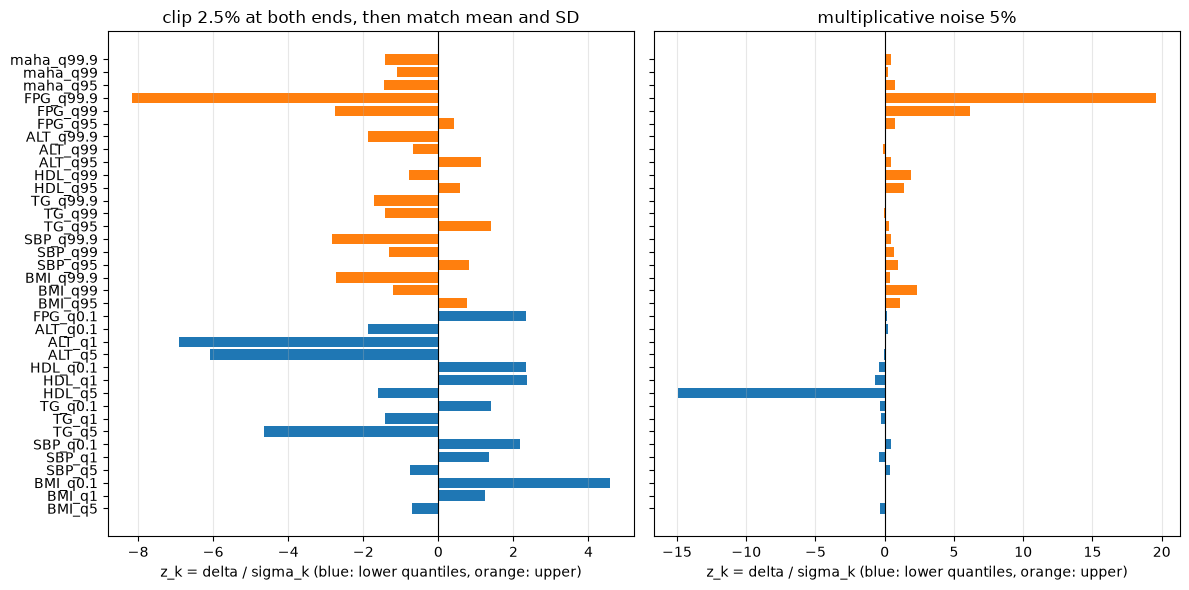

In [6]:
import matplotlib.pyplot as plt

_, z_clip = tail_by_formula(CLIPS['上下2.5%を削る'], B)
_, z_noise = tail_by_formula(NOISES['ノイズ 5%'], B)
order = [s for s in DN_NAMES + UP_NAMES if s in USED]
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, z, ttl in [(axes[0], z_clip, 'clip 2.5% at both ends, then match mean and SD'), (axes[1], z_noise, 'multiplicative noise 5%')]:
    vals = [z[s] for s in order]
    ax.barh(order, vals, color=['tab:blue' if s in DN_NAMES else 'tab:orange' for s in order])
    ax.axvline(0, color='k', lw=.8)
    ax.set_title(ttl); ax.set_xlabel('z_k = delta / sigma_k (blue: lower quantiles, orange: upper)')
    ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

左（端を削り、平均と標準偏差を合わせたもの）では、上側の 99・99.9 パーセンタイルが負に並びます。平均と標準偏差を合わせるために値を引き伸ばしたので、検査値の 95 パーセンタイルは逆に正になっています。同じ理由で、下側の 5 パーセンタイルは負になり、TG と ALT では 1 パーセンタイルも負になっています。右（ノイズ）では上側がおおむね正に並びます。HDL の 5 パーセンタイルは、標本のあいだの標準偏差 $\sigma_k$ が小さい分位点なので、値の変化が小さくても $z_k$ が大きくなります。FPG の 99.9 パーセンタイルは、値そのものが大きく動いています。FPG は追跡開始の時点で全員が 126 未満なので（`データはどう作られているか.md` の §2）、ノイズで 126 を超える人が出ると、上側の端が本物から大きく離れます。

## 5. 自分の C で確かめる

裾の一致は、採点結果の `detail` → `U_gen` → `tail_score` です。`detail` → `U_gen` → `tail` に、(a) と (b) の内訳（`u_shift`・`u_spike`・`shiftz`・`spike`・`mean_z_up`・`mean_z_dn`）と、採点に入った分位点の数 `n_stat` が入っています。分位点ごとの $z_k$ は出力されないので、どの分位点がずれたかは上の `tail_by_formula` で確かめてください。

In [7]:
t = score(NOISES['ノイズ 5%'])['detail']['U_gen']['tail']
{k: (round(v, 4) if isinstance(v, float) else v) for k, v in t.items()}

{'enabled': True,
 'u_shift': 0.6331,
 'u_spike': 0.4392,
 'shiftz': 4.8347,
 'spike': 0.2804,
 'mean_z_up': 1.8887,
 'mean_z_dn': -0.9949,
 'n_stat': 36}

自分の `C.csv` を、`starter/` と `participant_data/` が並んでいるフォルダに置き、そのフォルダで次のコマンドを実行すると、自己採点の `--json` の出力で同じ値を見られます。

```sh
cd starter
uv run python -m pwscup2026.kit.selfscore ../C.csv --dist ../participant_data --json
```

Docker を使う場合:

```sh
docker run --rm -v "$PWD":/w hajimeono/pwscup2026-kit:main-process-20260912 score /w/C.csv --dist /w/participant_data --json
```